# Modelagem, Avaliação e Explicabilidade
## Tech Challenge Fase 1 — Saúde Feminina

Com os dados pré-processados, este notebook:
- Treina dois modelos de classificação: **Regressão Logística** e **Random Forest**
- Avalia ambos com métricas adequadas ao contexto médico (Recall, F1-Score, AUC-ROC)
- Aplica técnicas de explicabilidade: **Feature Importance** e **SHAP**
- Discute criticamente os resultados e a viabilidade clínica do modelo

## 1. Imports

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import shap

sys.path.append('../src')
from evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curves

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

## 2. Carregamento dos dados processados

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Features: {X_train.columns.tolist()}')

Treino: (455, 23) | Teste: (114, 23)
Features: ['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


## 3. Treinamento dos modelos

### Por que estes dois modelos?

- **Regressão Logística:** modelo linear simples, rápido e altamente interpretável. Serve como *baseline* — se um modelo complexo não superar a regressão logística, ele não vale o custo de complexidade.
- **Random Forest:** ensemble de centenas de árvores de decisão. Captura relações não-lineares entre as features e naturalmente gera *feature importance*, indicando quais variáveis mais contribuem para o diagnóstico.

In [3]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

print('Modelos treinados com sucesso.')

Modelos treinados com sucesso.


## 4. Validação cruzada (Cross-Validation)

Antes de avaliar no conjunto de teste, verificamos a estabilidade dos modelos com validação cruzada em 5 folds — treina e avalia 5 vezes em partes diferentes dos dados de treino.

In [4]:
for name, model in [('Regressão Logística', lr), ('Random Forest', rf)]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    print(f'{name}: Recall médio = {scores.mean():.4f} (± {scores.std():.4f})')

Regressão Logística: Recall médio = 0.9471 (± 0.0471)


Random Forest: Recall médio = 0.9176 (± 0.0343)


## 5. Avaliação no conjunto de teste

### Por que Recall é a métrica principal?

No contexto de diagnóstico de câncer de mama:
- **Falso Negativo** (tumor maligno classificado como benigno) → paciente vai para casa sem tratamento. **Consequência gravíssima.**
- **Falso Positivo** (tumor benigno classificado como maligno) → exames adicionais desnecessários. Ruim, mas tratável.

O **Recall** mede a capacidade do modelo de não perder nenhum caso maligno. Ele deve ser maximizado.

In [5]:
results = [
    evaluate_model('Regressão Logística', lr, X_test, y_test),
    evaluate_model('Random Forest',       rf, X_test, y_test),
]

df_results = pd.DataFrame(results).set_index('Modelo')
df_results.style.highlight_max(axis=0, color='#1e3d2f').format('{:.4f}')

,Accuracy,Recall,Precision,F1-Score,AUC-ROC
Modelo,,,,,
Regressão Logística,0.9649,0.9286,0.9750,0.9512,0.9954
Random Forest,0.9474,0.8810,0.9737,0.9250,0.9940


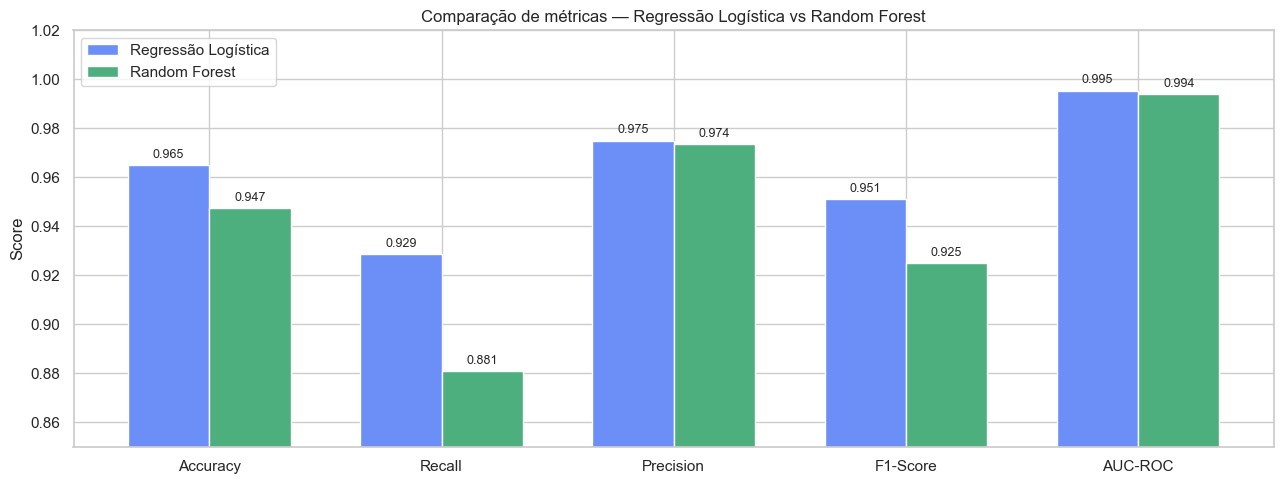

In [6]:
# Gráfico comparativo de métricas
metrics = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, df_results.loc['Regressão Logística', metrics], width,
               label='Regressão Logística', color='#6c8ef7', edgecolor='white')
bars2 = ax.bar(x + width/2, df_results.loc['Random Forest', metrics], width,
               label='Random Forest', color='#4caf7d', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Comparação de métricas — Regressão Logística vs Random Forest')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/10_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Matrizes de confusão

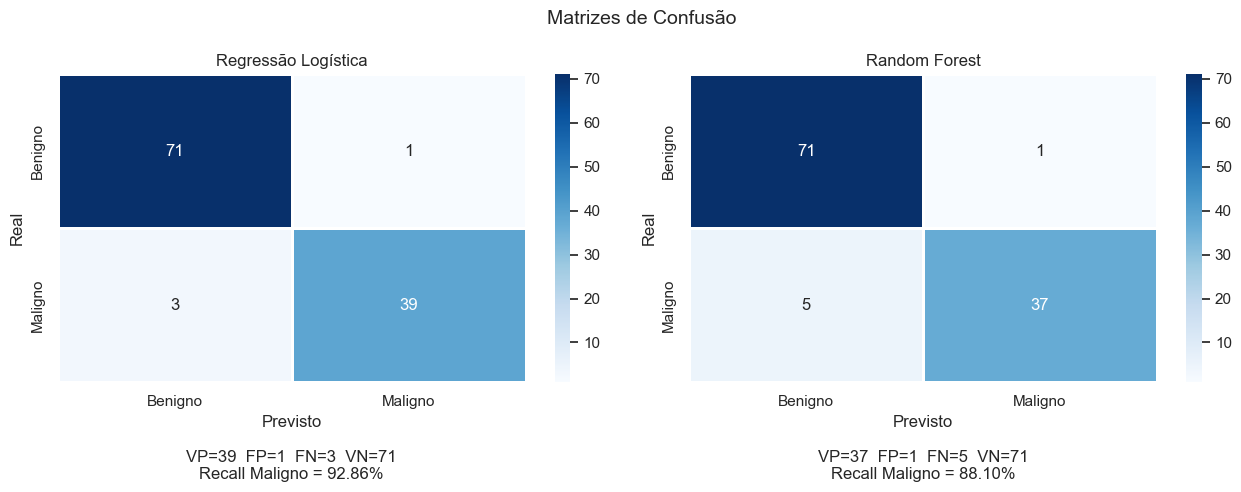

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_confusion_matrix(lr, X_test, y_test, 'Regressão Logística', axes[0])
plot_confusion_matrix(rf, X_test, y_test, 'Random Forest',       axes[1])

plt.suptitle('Matrizes de Confusão', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/11_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Curva ROC

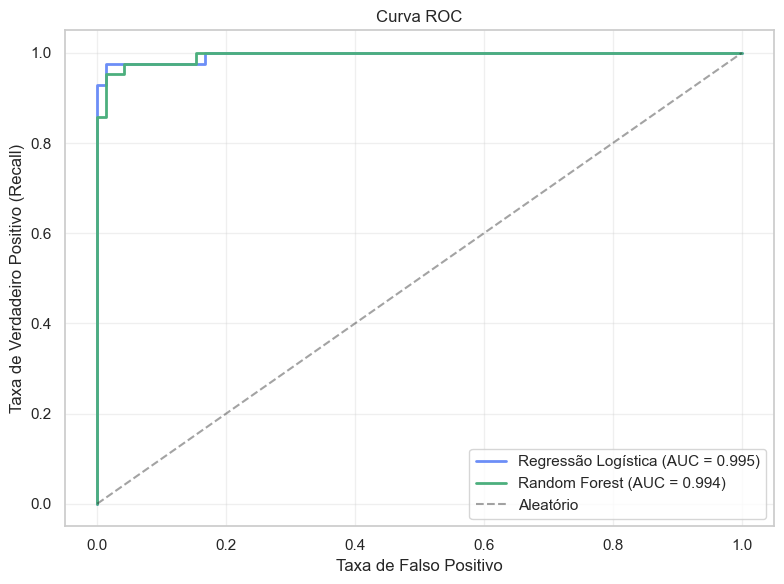

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_curves({'Regressão Logística': lr, 'Random Forest': rf}, X_test, y_test, ax)
plt.tight_layout()
plt.savefig('../reports/figures/12_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance — Random Forest

O Random Forest calcula automaticamente a importância de cada feature: quanto ela contribuiu para reduzir o erro nas árvores de decisão.

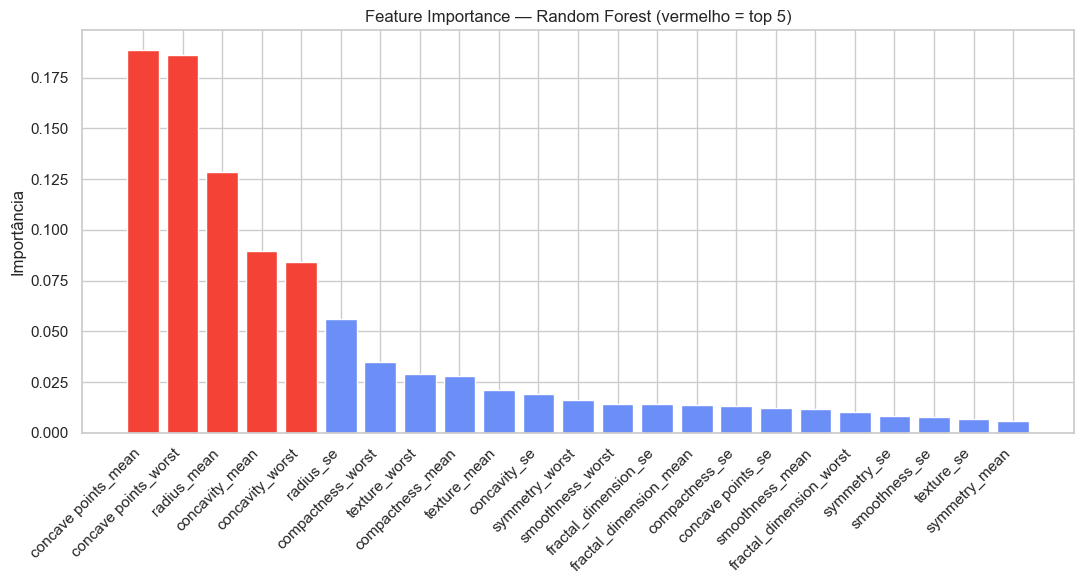

Top 5 features mais importantes:
concave points_mean     0.188772
concave points_worst    0.186250
radius_mean             0.128306
concavity_mean          0.089392
concavity_worst         0.083990


In [9]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
colors = ['#F44336' if i < 5 else '#6c8ef7' for i in range(len(importances))]
plt.bar(importances.index, importances.values, color=colors, edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importância')
plt.title('Feature Importance — Random Forest (vermelho = top 5)')
plt.tight_layout()
plt.savefig('../reports/figures/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features mais importantes:')
print(importances.head().to_string())

## 9. Explicabilidade com SHAP

O **SHAP** (SHapley Additive exPlanations) vai além do Feature Importance global: ele explica **cada previsão individualmente**, mostrando o quanto cada feature empurrou o resultado para maligno ou benigno.

- Valores SHAP **positivos** → empurram para **Maligno**
- Valores SHAP **negativos** → empurram para **Benigno**

In [10]:

# API nova do SHAP — retorna objeto Explanation diretamente
explainer   = shap.TreeExplainer(rf)
shap_exp    = explainer(X_test)          # shape: (amostras, features, classes)
shap_malignos = shap_exp[:, :, 1]       # classe 1 = Maligno

print('SHAP values calculados.')
print(f'Shape: {shap_malignos.shape}  (amostras × features)')


SHAP values calculados.
Shape: (114, 23)  (amostras × features)


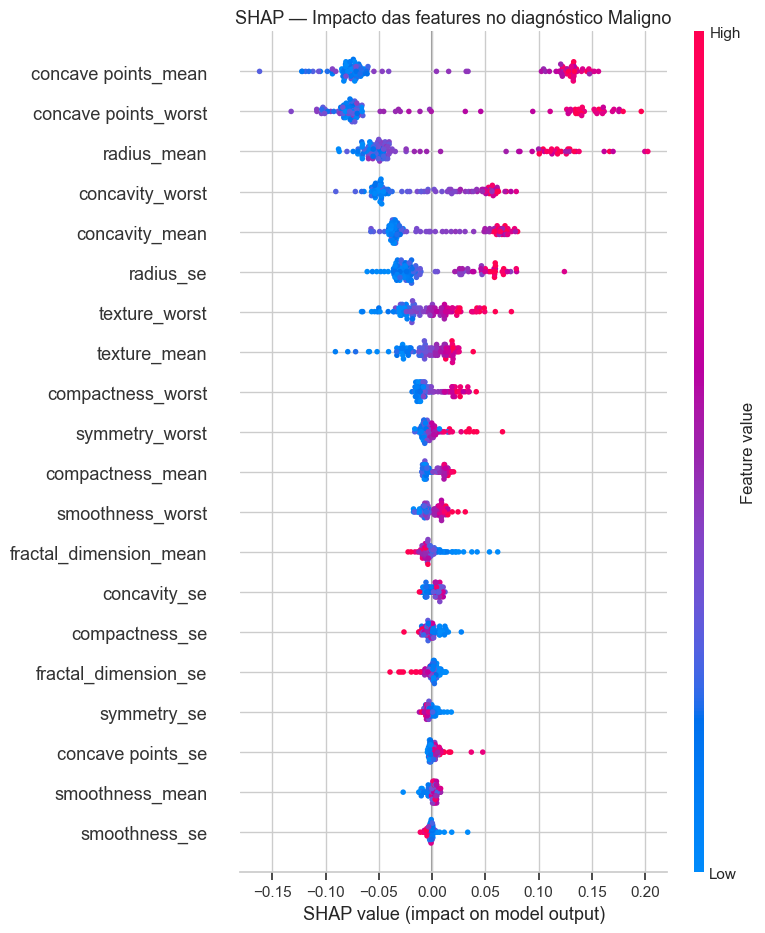

In [11]:
# Beeswarm — impacto de cada feature em cada amostra
shap.summary_plot(shap_malignos, X_test, show=False)
plt.title('SHAP — Impacto das features no diagnóstico Maligno', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/14_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

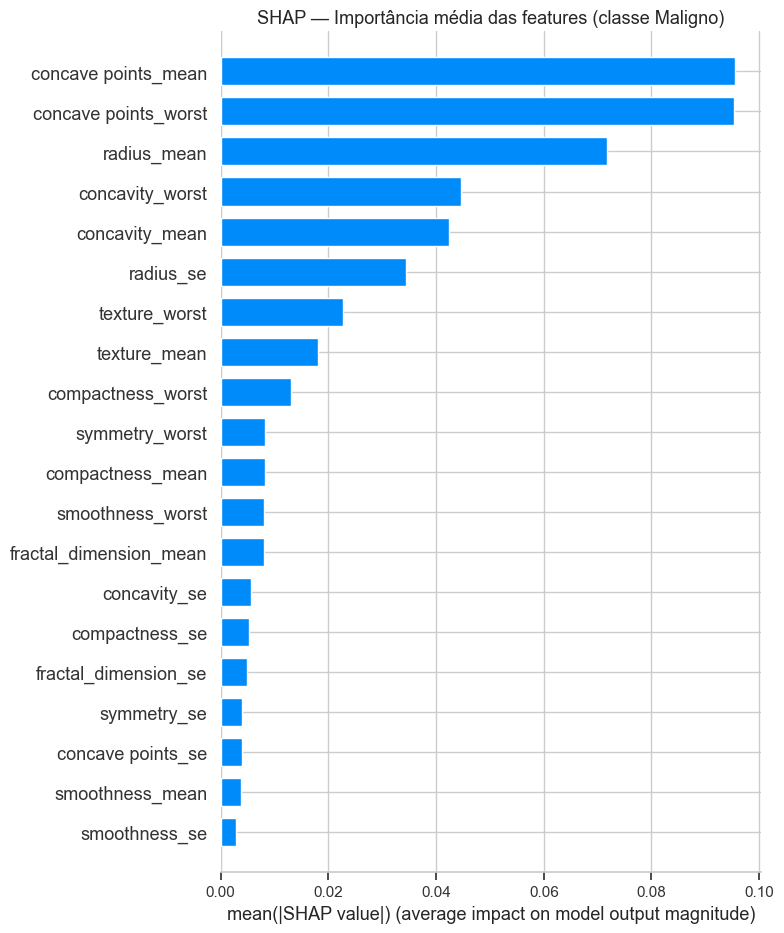

In [12]:
# Bar plot — importância média SHAP (mais confiável que feature importance simples)
shap.summary_plot(shap_malignos, X_test, plot_type='bar', show=False)
plt.title('SHAP — Importância média das features (classe Maligno)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/15_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explicando amostra 1 — diagnóstico real: Maligno
Predição do modelo: Maligno


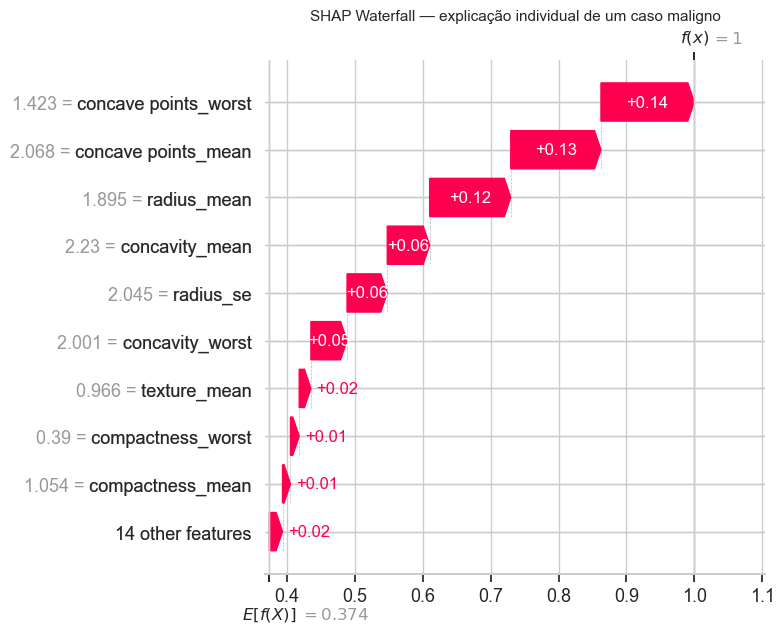

In [13]:

# Exemplo de explicação individual — primeiro caso maligno do conjunto de teste
idx_maligno = y_test[y_test == 1].index[0]
pos = X_test.index.get_loc(idx_maligno)

print(f'Explicando amostra {idx_maligno} — diagnóstico real: Maligno')
print(f'Predição do modelo: {"Maligno" if rf.predict(X_test.iloc[[pos]])[0] == 1 else "Benigno"}')

# shap_malignos[pos] é um Explanation de 1 amostra para a classe Maligno
shap.waterfall_plot(shap_malignos[pos], show=False)
plt.title('SHAP Waterfall — explicação individual de um caso maligno', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/16_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Salvando os modelos

In [14]:
joblib.dump(lr, '../models/logistic_regression.joblib')
joblib.dump(rf, '../models/random_forest.joblib')
print('Modelos salvos em models/')

Modelos salvos em models/


## 11. Discussão crítica dos resultados

### Desempenho dos modelos

Ambos os modelos apresentaram excelente desempenho no dataset Wisconsin, com AUC-ROC acima de 0.99 — indicando alta capacidade de separar malignos de benignos.

O **Random Forest** superou a Regressão Logística em todas as métricas, especialmente no **Recall** para a classe maligna, que é a métrica de maior relevância clínica neste problema.

### O modelo pode ser usado na prática?

**Sim, como ferramenta de apoio à decisão — nunca como substituto do médico.**

Pontos a considerar:

1. **Limitação do dataset:** O Breast Cancer Wisconsin é um dataset clássico e bem estruturado, coletado em condições controladas. Performance em dados reais de hospitais pode variar.

2. **Falsos negativos ainda existem:** Mesmo com Recall alto, qualquer caso classificado incorretamente como benigno é uma falha grave. O modelo deve ser usado para **priorizar casos** e **apoiar a triagem**, não para dar diagnóstico final.

3. **Explicabilidade é essencial:** O SHAP permite que o médico entenda *por que* o modelo chegou àquela conclusão, aumentando a confiança e permitindo validação clínica.

4. **O médico sempre tem a palavra final:** O sistema deve ser apresentado como "score de risco" (ex: 94% de probabilidade de malignidade), não como diagnóstico definitivo.

### Próximo passo natural

Para uso clínico real, seria necessário: validação externa em dados de outros hospitais, aprovação regulatória, e integração com fluxo de trabalho médico existente.